# Chapter 02 - Data and Sampling Distributions
## Enhanced Visual + Theory Edition

## Objectives
Understand sampling bias, sampling distributions, Central Limit Theorem, bootstrap, confidence intervals, and common probability distributions.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Population vs Sample
A sample is a subset of a population. Good samples should represent the population.

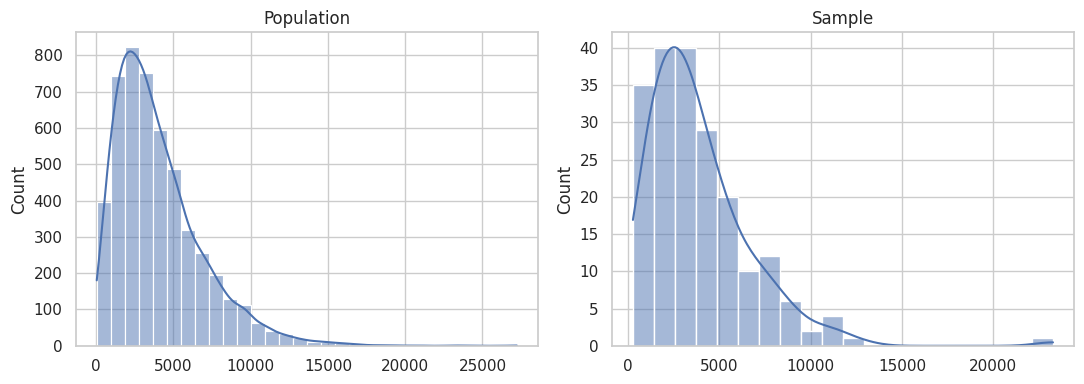

In [2]:
population=np.random.gamma(shape=2,scale=2000,size=5000)
sample=np.random.choice(population,200,replace=False)
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.histplot(population,bins=30,kde=True,ax=ax[0]); ax[0].set_title('Population')
sns.histplot(sample,bins=20,kde=True,ax=ax[1]); ax[1].set_title('Sample')
plt.tight_layout(); plt.show()

## 2. Sampling Bias
Bias occurs when the sample systematically differs from the population.

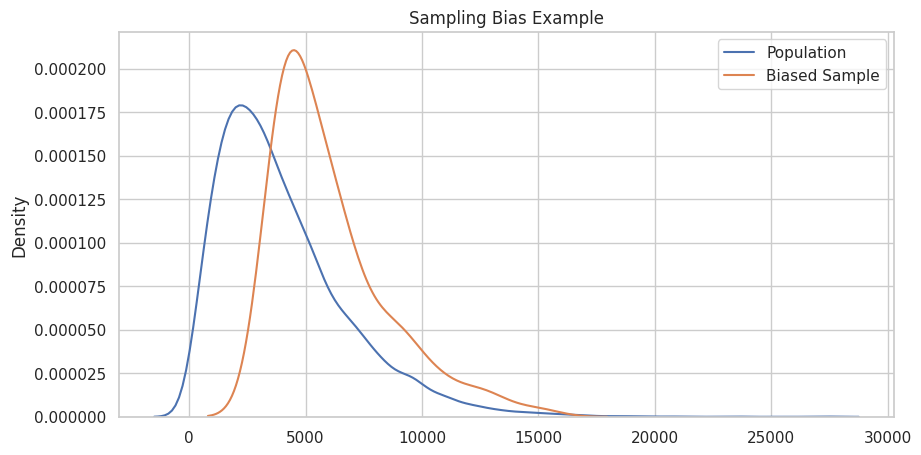

In [3]:
biased=population[population>np.median(population)][:200]
plt.figure(figsize=(10,5))
sns.kdeplot(population,label='Population')
sns.kdeplot(biased,label='Biased Sample')
plt.title('Sampling Bias Example'); plt.legend(); plt.show()

## 3. Sampling Distribution of the Mean
Repeated samples create a distribution of sample means.

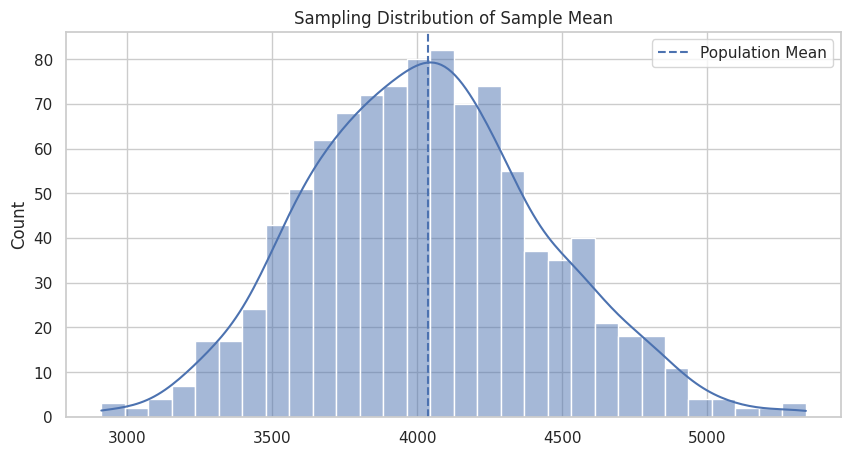

In [4]:
means=[]
for _ in range(1000):
    s=np.random.choice(population,50)
    means.append(np.mean(s))
plt.figure(figsize=(10,5))
sns.histplot(means,bins=30,kde=True)
plt.axvline(np.mean(population),ls='--',label='Population Mean')
plt.title('Sampling Distribution of Sample Mean'); plt.legend(); plt.show()

## 4. Central Limit Theorem
As sample size increases, sample means approach normality.

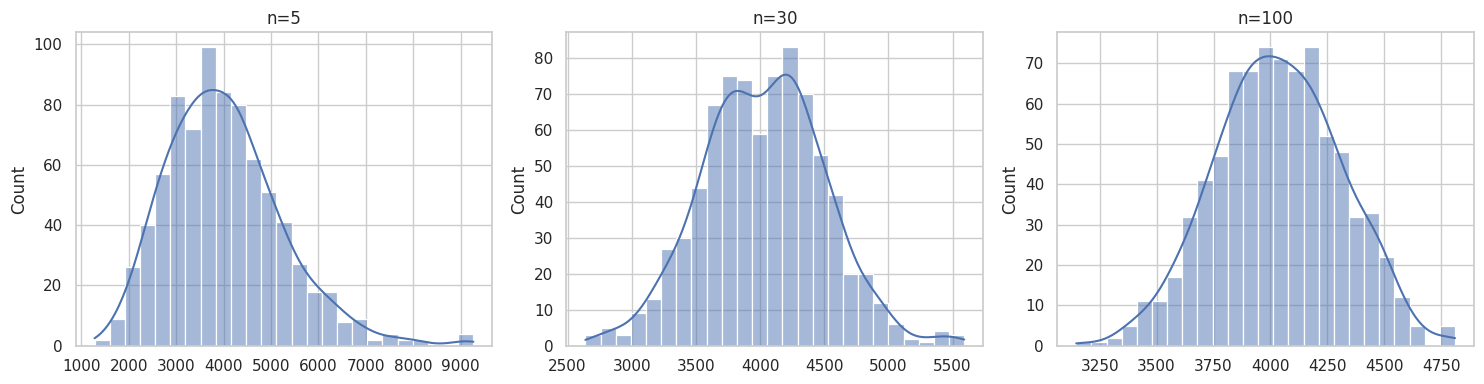

In [5]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
for i,n in enumerate([5,30,100]):
    vals=[np.mean(np.random.choice(population,n)) for _ in range(800)]
    sns.histplot(vals,bins=25,kde=True,ax=ax[i])
    ax[i].set_title(f'n={n}')
plt.tight_layout(); plt.show()

## 5. Bootstrap Resampling
Bootstrap estimates uncertainty by sampling with replacement.

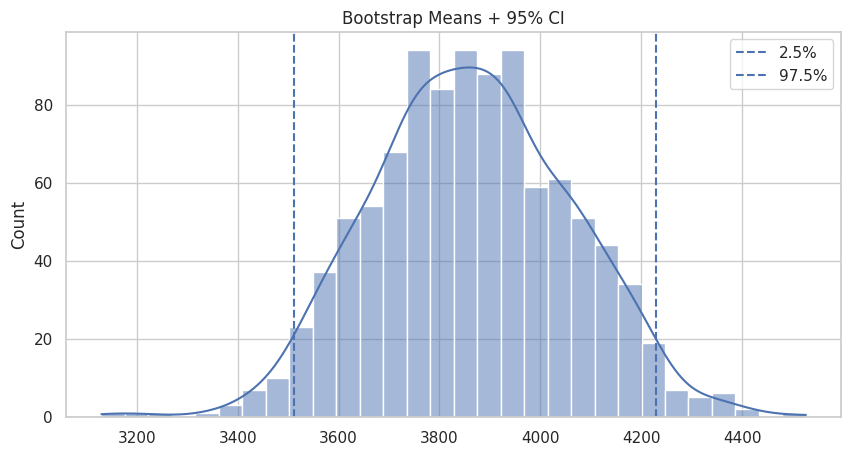

[3510.86361664 4229.39022392]


In [6]:
boot=[]
for _ in range(1000):
    b=np.random.choice(sample,size=len(sample),replace=True)
    boot.append(np.mean(b))
ci=np.percentile(boot,[2.5,97.5])
plt.figure(figsize=(10,5))
sns.histplot(boot,bins=30,kde=True)
plt.axvline(ci[0],ls='--',label='2.5%')
plt.axvline(ci[1],ls='--',label='97.5%')
plt.title('Bootstrap Means + 95% CI'); plt.legend(); plt.show()
print(ci)

## 6. Normal Distribution & QQ Plot

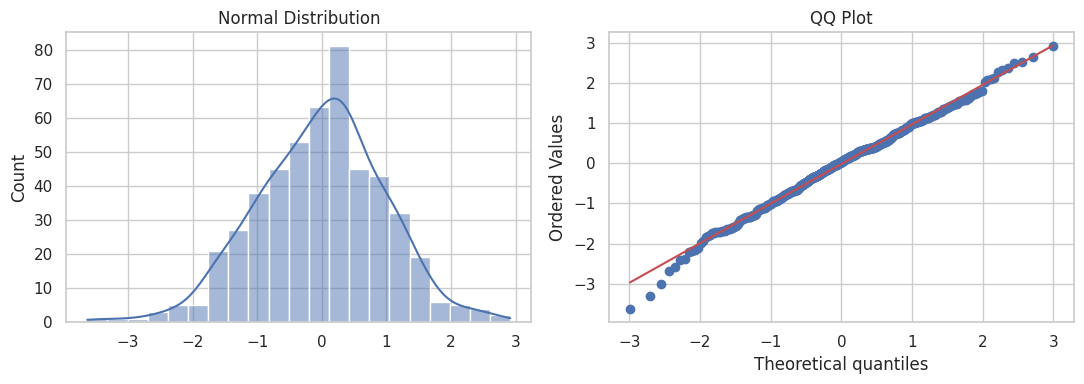

In [7]:
x=np.random.normal(0,1,500)
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.histplot(x,kde=True,ax=ax[0]); ax[0].set_title('Normal Distribution')
stats.probplot(x, dist='norm', plot=ax[1]); ax[1].set_title('QQ Plot')
plt.tight_layout(); plt.show()

## 7. Binomial and Poisson

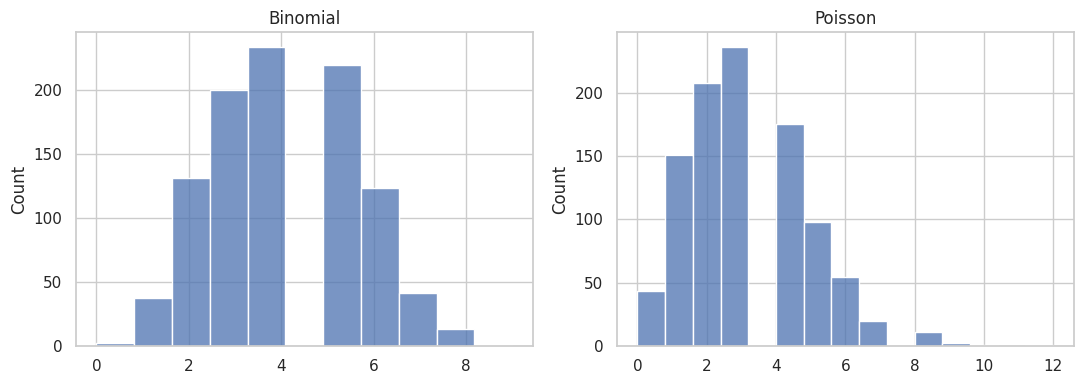

In [8]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
binom=np.random.binomial(10,0.4,1000)
pois=np.random.poisson(3,1000)
sns.histplot(binom,bins=11,ax=ax[0]); ax[0].set_title('Binomial')
sns.histplot(pois,bins=15,ax=ax[1]); ax[1].set_title('Poisson')
plt.tight_layout(); plt.show()

## Key Takeaways
1. Sample quality often matters more than sample size.
2. Repeated samples form sampling distributions.
3. CLT is foundational for inference.
4. Bootstrap is practical for uncertainty estimation.
5. Choose distributions based on data-generating process.